In [ ]:
%pip install pyspark pandas matplotlib seaborn nltk textblob

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [ ]:
df = spark.read.json("dbfs:/Volumes/workspace/default/amazon/Magazine_Subscriptions.jsonl")

In [ ]:
df.printSchema()
df.show(5)

root
 |-- asin: string (nullable = true)
 |-- helpful_vote: long (nullable = true)
 |-- images: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- attachment_type: string (nullable = true)
 |    |    |-- large_image_url: string (nullable = true)
 |    |    |-- medium_image_url: string (nullable = true)
 |    |    |-- small_image_url: string (nullable = true)
 |-- parent_asin: string (nullable = true)
 |-- rating: double (nullable = true)
 |-- text: string (nullable = true)
 |-- timestamp: long (nullable = true)
 |-- title: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- verified_purchase: boolean (nullable = true)

+----------+------------+------+-----------+------+--------------------+-------------+--------------------+--------------------+-----------------+
|      asin|helpful_vote|images|parent_asin|rating|                text|    timestamp|               title|             user_id|verified_purchase|
+----------+------------+-

In [ ]:
from pyspark.sql.functions import col

df_clean = df.select(col("asin").alias("p_id"),col("rating"),col("text").alias("review"),col("title").alias("review_title"),
col("helpful_vote"),col("verified_purchase"),col("timestamp")).dropna(subset=["rating"])   

In [ ]:
from pyspark.sql.functions import from_unixtime

df_time = df_text.withColumn(
    "review_date",
    from_unixtime(col("timestamp") / 1000).cast("date")
)

In [ ]:
from pyspark.sql.functions import year, month

df_time = df.withColumn("year", year("review_date")) \
.withColumn("month", month("review_date"))

In [ ]:
from pyspark.sql.functions import year, month, avg

df_time = df_text.withColumn("year", year("review_date")) \
                 .withColumn("month", month("review_date"))


In [ ]:
from pyspark.sql.functions import from_unixtime, year, month, col, length


df_text = df_clean.withColumn(
    "review_length",
    length(col("review"))
)


df_time = df_text.withColumn(
    "review_date",
    from_unixtime(col("timestamp") / 1000).cast("date")
).withColumn("year", year("review_date")) \
 .withColumn("month", month("review_date"))

df_time.printSchema()

root
 |-- p_id: string (nullable = true)
 |-- rating: double (nullable = true)
 |-- review: string (nullable = true)
 |-- review_title: string (nullable = true)
 |-- helpful_vote: long (nullable = true)
 |-- verified_purchase: boolean (nullable = true)
 |-- timestamp: long (nullable = true)
 |-- review_length: integer (nullable = true)
 |-- review_date: date (nullable = true)
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)



In [ ]:
from pyspark.sql.functions import lit

df_clean = df_clean.withColumn("category",lit("Magazine_Subscriptions"))

In [ ]:
q1 = df_time.groupBy("verified_purchase") \
             .avg("helpful_vote")
q1.show()

+-----------------+-----------------+
|verified_purchase|avg(helpful_vote)|
+-----------------+-----------------+
|            false| 8.73747251914184|
|             true|3.483946763626385|
+-----------------+-----------------+



In [ ]:



trend = df_time.groupBy("year", "month") \
.avg("rating") \
.orderBy("year", "month")

trend.show()

+----+-----+------------------+
|year|month|       avg(rating)|
+----+-----+------------------+
|2001|   10| 4.285714285714286|
|2001|   11| 4.268656716417911|
|2001|   12| 4.325581395348837|
|2002|    1|4.2407407407407405|
|2002|    2| 3.823529411764706|
|2002|    3|4.0285714285714285|
|2002|    4| 4.142857142857143|
|2002|    5|4.3478260869565215|
|2002|    6|               4.0|
|2002|    7|  4.54054054054054|
|2002|    8| 4.291666666666667|
|2002|    9| 4.161290322580645|
|2002|   10|3.8378378378378377|
|2002|   11| 4.173076923076923|
|2002|   12|4.2898550724637685|
|2003|    1| 4.173913043478261|
|2003|    2|               4.5|
|2003|    3| 4.241379310344827|
|2003|    4| 4.181818181818182|
|2003|    5|               4.2|
+----+-----+------------------+
only showing top 20 rows


In [ ]:
from pyspark.sql.functions import length, col

df_text = df_clean.withColumn(
    "review_length",
    length(col("review"))
)

In [ ]:
df_text.groupBy("helpful_vote") \
.avg("review_length") \
.show()

+------------+------------------+
|helpful_vote|avg(review_length)|
+------------+------------------+
|          10| 554.5400843881856|
|          51|          616.8125|
|          38| 653.9090909090909|
|          37|           809.125|
|          52| 772.9444444444445|
|          63|1010.6153846153846|
|          34| 746.8888888888889|
|          36| 878.3333333333334|
|         148|           1287.25|
|         145|            2654.0|
|           3| 315.4240631163708|
|          71|           766.625|
|         141|             922.0|
|         534|             251.0|
|         144|            1034.6|
|         724|             200.0|
|         281|             881.6|
|          79|             619.6|
|         596|             589.0|
|          42| 801.8333333333334|
+------------+------------------+
only showing top 20 rows


In [ ]:
from pyspark.sql.functions import udf,col
from textblob import TextBlob
from pyspark.sql.types import DoubleType

def get_sentiment(text):
    return float(TextBlob(text).sentiment.polarity)

sentiment_udf = udf(get_sentiment, DoubleType())

df_text = df_text.withColumn("sentiment", sentiment_udf(col("review")))


In [ ]:
from pyspark.sql.functions import col, length, udf
from textblob import TextBlob
from pyspark.sql.types import DoubleType


df_text = df_clean.withColumn(
    "review_length",
    length(col("review"))
)


def get_sentiment(text):
    if text is None:
        return 0.0
    return float(TextBlob(text).sentiment.polarity)

sentiment_udf = udf(get_sentiment, DoubleType())

df_text = df_text.withColumn(
    "sentiment",
    sentiment_udf(col("review"))
)

In [ ]:
df_text.groupBy("helpful_vote") \
.avg("sentiment") \
.show()

+------------+--------------------+
|helpful_vote|      avg(sentiment)|
+------------+--------------------+
|          10| 0.18543142936481807|
|          51| 0.16941156756022502|
|          38| 0.19305706910304518|
|          37| 0.17828496640417468|
|          52| 0.13001143868080742|
|          63|  0.1689842110144162|
|          34| 0.11189826310418477|
|          36| 0.18261663929115063|
|         148| 0.22167051540317678|
|         145| 0.15897302102659247|
|           3| 0.21287009358582357|
|          71| 0.18886701309311604|
|         141| 0.16257936507936507|
|         534|-0.08333333333333333|
|         144| 0.19998133116883116|
|         724|-0.00624999999999...|
|         281| 0.01805506596578025|
|          79| 0.09444094862663177|
|         596|-0.10486111111111113|
|          42| 0.10730852644579124|
+------------+--------------------+
only showing top 20 rows


In [ ]:
pdf = df_text.sample(0.02).toPandas()

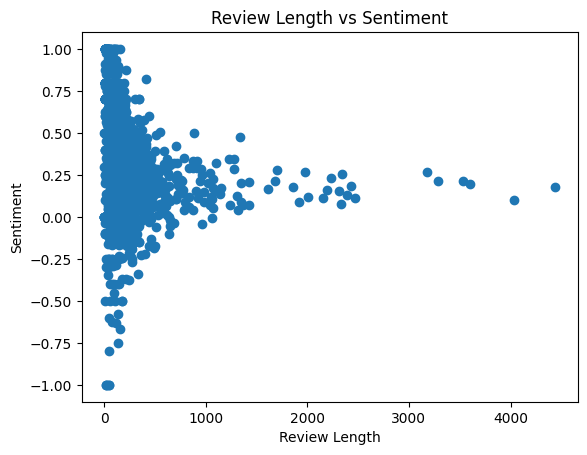

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(pdf["review_length"], pdf["sentiment"])
plt.xlabel("Review Length")
plt.ylabel("Sentiment")
plt.title("Review Length vs Sentiment")
plt.show()

In [ ]:
top_products = df_clean.groupBy("p_id") \
    .count() \
    .orderBy("count", ascending=False) \
    .limit(10)

top_products.display()

p_id,count
B00005NIOH,1586
B002PXVYEQ,1479
B004GVZUUY,1381
B002PXW1IE,1155
B000063XJL,1068
B001THPA58,921
B002CT515Q,841
B001THPA26,828
B0089FUF6W,816
B003N3QRF8,727


In [ ]:
rating_dist = df_clean.groupBy("rating").count().orderBy("rating")
rating_dist.display()

rating,count
1.0,9685
2.0,3953
3.0,5033
4.0,8206
5.0,44620


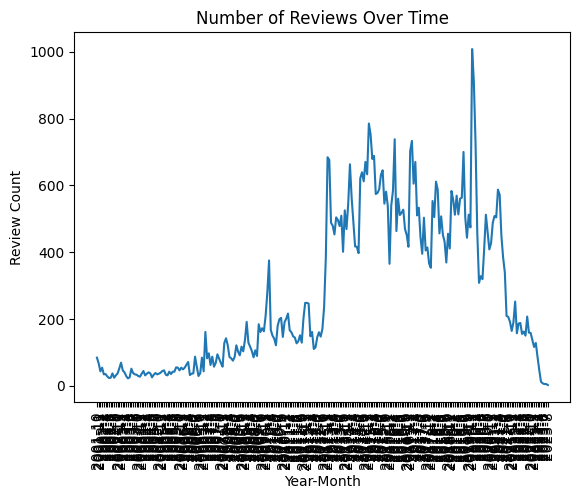

In [ ]:
import matplotlib.pyplot as plt

pdf = trend.toPandas()

pdf["date"] = pdf["year"].astype(str) + "-" + pdf["month"].astype(str)

plt.figure()
plt.plot(pdf["date"], pdf["count"])
plt.xticks(rotation=90)
plt.title("Number of Reviews Over Time")
plt.xlabel("Year-Month")
plt.ylabel("Review Count")
plt.show()

In [ ]:
df1 = spark.read.json("/Volumes/workspace/default/amazon/Subscription_Boxes.jsonl")

In [ ]:
df1 . printSchema()
df1.show()

root
 |-- asin: string (nullable = true)
 |-- helpful_vote: long (nullable = true)
 |-- images: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- attachment_type: string (nullable = true)
 |    |    |-- large_image_url: string (nullable = true)
 |    |    |-- medium_image_url: string (nullable = true)
 |    |    |-- small_image_url: string (nullable = true)
 |-- parent_asin: string (nullable = true)
 |-- rating: double (nullable = true)
 |-- text: string (nullable = true)
 |-- timestamp: long (nullable = true)
 |-- title: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- verified_purchase: boolean (nullable = true)

+----------+------------+--------------------+-----------+------+--------------------+-------------+--------------------+--------------------+-----------------+
|      asin|helpful_vote|              images|parent_asin|rating|                text|    timestamp|               title|             user_id|verified_purchase

In [ ]:
from pyspark.sql.functions import col

df1_clean = df1.select(
    col("asin").alias("p_id"),
    col("rating"),
    col("text").alias("review"),
    col("title").alias("review_title"),
    col("helpful_vote"),
    col("verified_purchase"),
    col("timestamp")
)

In [ ]:
from pyspark.sql.functions import from_unixtime, year, month, col, length


df1_text = df1_clean.withColumn(
    "review_length",
    length(col("review"))
)


df1_time = df1_text.withColumn(
    "review_date",
    from_unixtime(col("timestamp") / 1000).cast("date")
).withColumn("year", year("review_date")) \
 .withColumn("month", month("review_date"))

df1_time.printSchema()

root
 |-- p_id: string (nullable = true)
 |-- rating: double (nullable = true)
 |-- review: string (nullable = true)
 |-- review_title: string (nullable = true)
 |-- helpful_vote: long (nullable = true)
 |-- verified_purchase: boolean (nullable = true)
 |-- timestamp: long (nullable = true)
 |-- review_length: integer (nullable = true)
 |-- review_date: date (nullable = true)
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)



In [ ]:
from pyspark.sql.functions import length

df1_text = df1_clean.withColumn(
    "review_length",
    length(col("review"))
)

In [ ]:
from pyspark.sql.functions import from_unixtime

df1_text = df1_text.withColumn(
    "review_date",
    from_unixtime(col("timestamp") / 1000).cast("date")
)

In [ ]:
from pyspark.sql.functions import year, month, avg

df1_time = df1_text.withColumn("year", year("review_date")) \
                 .withColumn("month", month("review_date"))


In [ ]:
df1_time.groupBy("year", "month") \
       .avg("rating") \
       .show()

+----+-----+------------------+
|year|month|       avg(rating)|
+----+-----+------------------+
|2021|    1| 3.537170263788969|
|2019|   10|        3.89453125|
|2020|    6|3.8720238095238093|
|2022|    9|3.8843537414965987|
|2021|    9|             3.875|
|2019|    4| 4.084291187739463|
|2020|    1|3.8069767441860467|
|2018|    8| 3.467576791808874|
|2017|    4| 4.055555555555555|
|2018|    7|3.2972972972972974|
|2018|   11| 3.633744855967078|
|2020|    4|3.6036036036036037|
|2020|    9|3.8233830845771144|
|2023|    1|              3.75|
|2018|   10|3.6363636363636362|
|2019|    1|3.6988847583643123|
|2017|    3|3.3684210526315788|
|2017|   10| 4.351351351351352|
|2022|    8| 3.758974358974359|
|2018|    6| 4.009708737864078|
+----+-----+------------------+
only showing top 20 rows


In [ ]:
df1_text.groupBy("p_id") \
       .count() \
       .orderBy("count", ascending=False) \
       .show()

+----------+-----+
|      p_id|count|
+----------+-----+
|B0742LVLMJ| 1772|
|B07G584SHG|  600|
|B07VGNQD8K|  572|
|B01M71IUZ7|  545|
|B01M7UD21X|  486|
|B01M7UDAVI|  416|
|B07NVL6TJG|  332|
|B07DNM6GBC|  295|
|B07MGJZ2MH|  241|
|B07F8Y6BH9|  227|
|B095WFPM47|  218|
|B07DNLG9ZR|  201|
|B07R7WVRGL|  196|
|B07DNML26P|  188|
|B07RBYJN37|  176|
|B07DNKDLYV|  172|
|B07DNLPCB9|  162|
|B07QL1JRCN|  161|
|B07XGNHYC2|  148|
|B07FT4FMWX|  147|
+----------+-----+
only showing top 20 rows


In [ ]:
from pyspark.sql.functions import udf
from textblob import TextBlob
from pyspark.sql.types import DoubleType

def get_sentiment(text):
    if text is None:
        return 0.0
    return float(TextBlob(text).sentiment.polarity)

sentiment_udf = udf(get_sentiment, DoubleType())

df1_text = df1_text.withColumn(
    "sentiment",
    sentiment_udf(col("review"))
)

In [ ]:
df1_text.groupBy("helpful_vote") \
       .avg("sentiment") \
       .show()

+------------+--------------------+
|helpful_vote|      avg(sentiment)|
+------------+--------------------+
|          30|0.013339263301595893|
|          29| 0.10438337078156894|
|          33| 0.15480372698289363|
|          93| 0.14739959114959114|
|          28| 0.13234425520091933|
|           9| 0.14689235395690312|
|          11| 0.14604395874664192|
|         475| 0.26187697437697444|
|          59| 0.09255735930735932|
|          32| 0.11080021001629248|
|          49| 0.13427560425685425|
|          17| 0.09662752765922435|
|          14| 0.10632985688874819|
|         104|  0.1819501879699248|
|          35| 0.05701785368680972|
|           3|  0.2511224658020033|
|         985|  0.2816666666666667|
|         264|0.061580086580086575|
|           4| 0.21947119500056675|
|          23|  0.1346857440644374|
+------------+--------------------+
only showing top 20 rows


In [ ]:
df1_text.groupBy("helpful_vote") \
       .avg("review_length") \
       .show()

+------------+------------------+
|helpful_vote|avg(review_length)|
+------------+------------------+
|          30|          485.5625|
|          29|         504.03125|
|          33|424.95238095238096|
|          93|             611.0|
|          28| 513.9655172413793|
|           9| 350.0931899641577|
|          11| 405.7393162393162|
|         475|            2049.0|
|          59|             544.6|
|          32| 561.4583333333334|
|          49|           442.375|
|          17|392.56043956043953|
|          14|431.11920529801324|
|         104|            875.75|
|          35| 614.5384615384615|
|           3|254.05384063173008|
|         985|            1773.0|
|         264|             574.0|
|           4| 262.4318407960199|
|          23| 486.0925925925926|
+------------+------------------+
only showing top 20 rows


In [ ]:
from pyspark.sql.functions import year, month, avg

df1_time = df1_text.withColumn("year", year("review_date")) \
                 .withColumn("month", month("review_date"))

trend = df1_time.groupBy("year", "month") \
               .agg(avg("rating").alias("avg_rating")) \
               .orderBy("year", "month")

trend.show()

+----+-----+------------------+
|year|month|        avg_rating|
+----+-----+------------------+
|2017|    1| 3.358974358974359|
|2017|    2|3.6785714285714284|
|2017|    3|3.3684210526315788|
|2017|    4| 4.055555555555555|
|2017|    5| 4.514705882352941|
|2017|    6| 4.264705882352941|
|2017|    7| 4.273809523809524|
|2017|    8| 4.225225225225225|
|2017|    9| 4.230769230769231|
|2017|   10| 4.351351351351352|
|2017|   11| 3.909090909090909|
|2017|   12|3.8548387096774195|
|2018|    1|  4.08080808080808|
|2018|    2| 4.377358490566038|
|2018|    3|3.9420289855072466|
|2018|    4|3.9381443298969074|
|2018|    5| 3.857142857142857|
|2018|    6| 4.009708737864078|
|2018|    7|3.2972972972972974|
|2018|    8| 3.467576791808874|
+----+-----+------------------+
only showing top 20 rows


In [ ]:
from pyspark.sql.functions import length

df1_text = df1_clean.withColumn("review_length", length("review"))

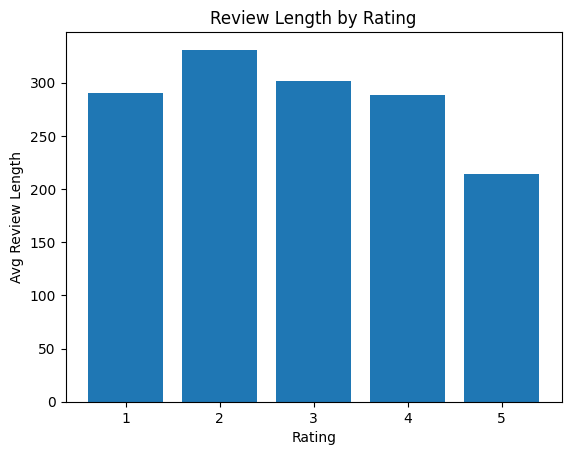

In [ ]:
len_rating = df1_text.groupBy("rating").avg("review_length").orderBy("rating")

pdf = len_rating.toPandas()

plt.figure()
plt.bar(pdf["rating"], pdf["avg(review_length)"])
plt.title("Review Length by Rating")
plt.xlabel("Rating")
plt.ylabel("Avg Review Length")
plt.show()